In [1]:
# Kaggle has pandas, sklearn, xgboost, networkx, torch preinstalled.
# Only PyTorch Geometric needs installing.
!pip install -q torch_geometric

import torch, xgboost
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("xgboost:", xgboost.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.1 MB/s eta 0:00:00
torch: 2.10.0+cu128 | CUDA: True
xgboost: 3.2.0


In [3]:
import glob, os
import pandas as pd
import numpy as np

COLUMNS = [
    'TransactionID', 'isFraud', 'TransactionDT', 'TransactionAMT', 'ProductCD',
    'card1', 'card4', 'card6', 'addr1', 'dist1', 'P_emaildomain', 'C1', 'C2',
    'C5', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D10', 'D15'
]

# 1) Find every candidate and inspect its header (nrows=0 -> instant, even on 654 MB files)
candidates = sorted(glob.glob('/kaggle/input/**/train_transaction.csv', recursive=True))
assert candidates, "train_transaction.csv not found - attach the IEEE-CIS dataset via + Add Input"

best_path, best_matches, best_size = None, -1, -1
for p in candidates:
    size_mb = os.path.getsize(p) / 1e6
    header = pd.read_csv(p, nrows=0).columns.tolist()
    matches = len([c for c in COLUMNS if c in header])
    print(f"{p}  |  {size_mb:,.1f} MB  |  {matches}/{len(COLUMNS)} columns match")
    if matches > best_matches or (matches == best_matches and size_mb > best_size):
        best_path, best_matches, best_size = p, matches, size_mb

DATA_PATH = best_path
print(f"\nUsing: {DATA_PATH}")

# 2) Warn loudly if even the best file is incomplete
if best_matches < len(COLUMNS):
    header = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
    missing = [c for c in COLUMNS if c not in header]
    print(f"\n*** WARNING: {len(missing)} column(s) missing in this file: {missing}")
    print("*** This looks like a truncated/sample copy. Attach the FULL dataset and re-run.")
    COLUMNS = [c for c in COLUMNS if c in header]   # proceed with what's available

df = pd.read_csv(DATA_PATH, usecols=COLUMNS)
print("Loaded:", df.shape)
print("Sanity check: the full dataset has ~590,540 rows. If you see far fewer, it's a subset file.")
df.head()

/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv  |  683.4 MB  |  21/22 columns match

Using: /kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv

*** WARNING: 1 column(s) missing in this file: ['TransactionAMT']
*** This looks like a truncated/sample copy. Attach the FULL dataset and re-run.
Loaded: (590540, 21)
Sanity check: the full dataset has ~590,540 rows. If you see far fewer, it's a subset file.


,TransactionID,isFraud,TransactionDT,ProductCD,card1,card4,card6,addr1,dist1,P_emaildomain,...,C2,C5,C13,C14,D1,D2,D3,D4,D10,D15
0,2987000,0,86400,W,13926,discover,credit,315.0,19.0,NaN,...,1.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,13.0,0.0
1,2987001,0,86401,W,2755,mastercard,credit,325.0,NaN,gmail.com,...,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,0.0,0.0
2,2987002,0,86469,W,4663,visa,debit,330.0,287.0,outlook.com,...,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,0.0,315.0
3,2987003,0,86499,W,18132,mastercard,debit,476.0,NaN,yahoo.com,...,5.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,84.0,111.0
4,2987004,0,86506,H,4497,mastercard,credit,420.0,NaN,gmail.com,...,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN


Using most recent transactions: (150000, 20)
Train: (105000, 18) | Val: (22500, 18) | Test: (22500, 18)


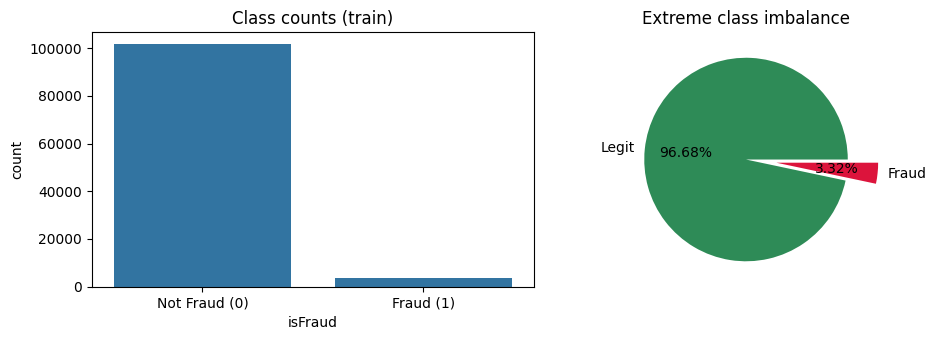

Fraudulent transactions in train: 3483 (3.32%)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Most recent 150k transactions (chronological)
df = df.sort_values('TransactionDT').tail(150_000).reset_index(drop=True)
df = df.drop('TransactionDT', axis=1)
print("Using most recent transactions:", df.shape)

categorical_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'card1', 'addr1']
numerical_cols = [c for c in df.columns if c not in categorical_cols + ['TransactionID', 'isFraud']]

# 2) Missing values
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
df[categorical_cols] = df[categorical_cols].fillna('unknown')

# 3) Keep copy for graph construction (BEFORE encoding)
df_for_graph = df.copy()

# 4) Encode categoricals for baselines
encoded_df = df.copy()
for col in categorical_cols:
    encoded_df[col] = LabelEncoder().fit_transform(encoded_df[col].astype(str))
encoded_df = encoded_df.drop('TransactionID', axis=1)

X = encoded_df.drop('isFraud', axis=1)
y = encoded_df['isFraud']

# 5) Chronological 70/15/15 (shuffle=False -> contiguous; indices align with graph masks)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, shuffle=False)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, shuffle=False)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# 6) Class imbalance plot
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.countplot(x=y_train, ax=ax[0])
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])
ax[0].set_title('Class counts (train)')
ax[1].pie(y_train.value_counts(), labels=['Legit', 'Fraud'],
          autopct='%.2f%%', colors=['seagreen', 'crimson'], explode=(0, 0.3))
ax[1].set_title('Extreme class imbalance')
plt.tight_layout(); plt.show()
print(f"Fraudulent transactions in train: {int(y_train.sum())} ({100*y_train.mean():.2f}%)")

In [5]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score

results, models = {}, {}

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}\n")

# --- Logistic Regression ---
print("Training Logistic Regression...")
lr = LogisticRegression(solver='liblinear', class_weight='balanced',
                        max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
models['Logistic Regression'] = lr

# --- XGBoost (xgboost >= 2.0: early_stopping_rounds in CONSTRUCTOR) ---
print("Training XGBoost...")
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    random_state=42
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
models['XGBoost'] = xgb

# --- Evaluate both on the SAME test set ---
for name, mdl in models.items():
    proba = mdl.predict_proba(X_test)[:, 1]
    preds = (proba > 0.5).astype(int)
    results[name] = {'AUC': roc_auc_score(y_test, proba),
                     'F1': f1_score(y_test, preds),
                     'Recall': recall_score(y_test, preds),
                     'test_pred_proba': proba}
    m = results[name]
    print(f"{name:20s} | AUC {m['AUC']:.4f} | F1 {m['F1']:.4f} | Recall {m['Recall']:.4f}")

scale_pos_weight = 29.15

Training Logistic Regression...
Training XGBoost...
Logistic Regression  | AUC 0.7974 | F1 0.1808 | Recall 0.6883
XGBoost              | AUC 0.8964 | F1 0.3163 | Recall 0.7256


In [6]:
import torch
from torch_geometric.data import HeteroData

print("Building heterogeneous graph (vectorized)...")

graph_df = df_for_graph.copy().reset_index(drop=True)
feat_cols = [c for c in graph_df.columns
             if c not in ['TransactionID', 'isFraud', 'ProductCD',
                          'card4', 'card6', 'card1', 'addr1', 'P_emaildomain']]

hetero_data = HeteroData()
txn_x = torch.tensor(graph_df[feat_cols].values, dtype=torch.float)
hetero_data['transaction'].x = txn_x
hetero_data['transaction'].y = torch.tensor(graph_df['isFraud'].values, dtype=torch.long)
n_txn = txn_x.shape[0]
txn_idx = np.arange(n_txn)
print(f"{n_txn} transaction nodes | {txn_x.shape[1]} features each")

for anchor in ['card1', 'addr1', 'P_emaildomain']:
    vals = graph_df[anchor].astype(str).values
    uniq, inv = np.unique(vals, return_inverse=True)   # value -> anchor id (vectorized)
    n_a = len(uniq)
    inv_t = torch.tensor(inv, dtype=torch.long)

    # edges (both directions)
    hetero_data['transaction', 'to', anchor].edge_index = torch.tensor(
        np.vstack([txn_idx, inv]), dtype=torch.long)
    hetero_data[anchor, 'rev_to', 'transaction'].edge_index = torch.tensor(
        np.vstack([inv, txn_idx]), dtype=torch.long)

    # anchor features = mean of connected transaction features (one scatter op)
    sums = torch.zeros(n_a, txn_x.shape[1])
    sums.index_add_(0, inv_t, txn_x)
    cnt = torch.bincount(inv_t, minlength=n_a).clamp(min=1).unsqueeze(1).float()
    hetero_data[anchor].x = sums / cnt
    print(f"  {anchor:14s}: {n_a} anchor nodes | {n_txn} edges")

print("\n", hetero_data)

Building heterogeneous graph (vectorized)...
150000 transaction nodes | 12 features each
  card1         : 7784 anchor nodes | 150000 edges
  addr1         : 118 anchor nodes | 150000 edges
  P_emaildomain : 60 anchor nodes | 150000 edges

 HeteroData(
  transaction={
    x=[150000, 12],
    y=[150000],
  },
  card1={ x=[7784, 12] },
  addr1={ x=[118, 12] },
  P_emaildomain={ x=[60, 12] },
  (transaction, to, card1)={ edge_index=[2, 150000] },
  (card1, rev_to, transaction)={ edge_index=[2, 150000] },
  (transaction, to, addr1)={ edge_index=[2, 150000] },
  (addr1, rev_to, transaction)={ edge_index=[2, 150000] },
  (transaction, to, P_emaildomain)={ edge_index=[2, 150000] },
  (P_emaildomain, rev_to, transaction)={ edge_index=[2, 150000] }
)


In [16]:
# ===== CELL 6 (FIXED) — pad y_flat to full graph size =====
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv
from sklearn.metrics import roc_auc_score, f1_score, recall_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. Flatten heterogeneous graph ---
hd_cpu = hetero_data.cpu()
ntypes = [t for t in ['transaction', 'card1', 'addr1', 'P_emaildomain'] if t in hd_cpu.node_types]
X_parts, offsets = [], {}
off = 0
for t in ntypes:
    X_parts.append(hd_cpu[t].x)
    offsets[t] = off
    off += hd_cpu[t].x.shape[0]

X_flat = torch.cat(X_parts, dim=0)
n_txn = hd_cpu['transaction'].num_nodes
N_total = X_flat.shape[0]

# THE FIX: pad labels with -1 for anchor nodes so y covers all N_total nodes
y_flat = torch.cat([hd_cpu['transaction'].y,
                    torch.full((N_total - n_txn,), -1, dtype=torch.long)])
print(f"Flattened: {N_total} nodes | labels: {len(y_flat)} (transaction {n_txn} + anchors {N_total-n_txn})")

# --- 2. Combine edge types with offsets ---
edge_parts = []
for (s, r, d) in hd_cpu.edge_types:
    ei = hd_cpu[s, r, d].edge_index
    edge_parts.append(torch.stack([ei[0] + offsets[s], ei[1] + offsets[d]], dim=0))
edge_index_flat = torch.cat(edge_parts, dim=1)

# --- 3. Masks (only transaction positions are True, so -1 anchors are never used) ---
train_mask = torch.zeros(N_total, dtype=torch.bool); train_mask[torch.tensor(X_train.index.values)] = True
val_mask   = torch.zeros(N_total, dtype=torch.bool); val_mask[torch.tensor(X_val.index.values)]   = True
test_mask  = torch.zeros(N_total, dtype=torch.bool); test_mask[torch.tensor(X_test.index.values)] = True

# --- 4. To device ---
X_flat, y_flat, edge_index_flat = X_flat.to(device), y_flat.to(device), edge_index_flat.to(device)
train_mask, val_mask, test_mask = train_mask.to(device), val_mask.to(device), test_mask.to(device)
print(f"Train {train_mask.sum().item()} | Val {val_mask.sum().item()} | Test {test_mask.sum().item()}")

# --- 5. Model ---
class FraudGNN(torch.nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2, heads=4):
        super().__init__()
        self.gcn1 = GCNConv(in_dim, hidden)
        self.gat  = GATv2Conv(hidden, hidden // heads, heads=heads)
        self.lin  = torch.nn.Linear(hidden, out_dim)

    def forward(self, x, edge_index):
        h = F.relu(self.gcn1(x, edge_index))
        h = F.relu(self.gat(h, edge_index))
        return self.lin(h)

model = FraudGNN(X_flat.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# --- 6. Weighted CE ---
c0, c1 = (y_train == 0).sum(), (y_train == 1).sum()
n = len(y_train)
class_weights = torch.tensor([n/(2*c0), n/(2*c1)], dtype=torch.float, device=device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

def train_epoch():
    model.train(); optimizer.zero_grad()
    out = model(X_flat, edge_index_flat)
    loss = criterion(out[train_mask], y_flat[train_mask])   # safe: mask ⊂ transaction region
    loss.backward(); optimizer.step()
    return loss.item()

@torch.no_grad()
def predict_proba_all():
    model.eval()
    out = model(X_flat, edge_index_flat)
    return torch.softmax(out, dim=1)[:, 1].cpu().numpy()

# --- 7. Train with early stopping ---
print("\nTraining GNN...")
best_val_auc, patience, wait = 0.0, 50, 0
for epoch in range(1, 201):
    loss = train_epoch()
    probs = predict_proba_all()
    val_auc = roc_auc_score(y_flat[val_mask].cpu().numpy(), probs[val_mask.cpu().numpy()])
    if val_auc > best_val_auc:
        best_val_auc, wait = val_auc, 0
        torch.save(model.state_dict(), 'best_gnn_model.pt')
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}"); break
    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss {loss:.4f} | val AUC {val_auc:.4f}")

# --- 8. Test evaluation ---
model.load_state_dict(torch.load('best_gnn_model.pt'))
probs = predict_proba_all()
y_test_gnn = y_flat[test_mask].cpu().numpy()   # all valid labels (mask ⊂ transactions)
p_test = probs[test_mask.cpu().numpy()]
preds = (p_test > 0.5).astype(int)

results['GNN (GCN+GAT)'] = {'AUC': roc_auc_score(y_test_gnn, p_test),
                            'F1': f1_score(y_test_gnn, preds),
                            'Recall': recall_score(y_test_gnn, preds),
                            'test_pred_proba': p_test,
                            'test_labels': y_test_gnn}
m = results['GNN (GCN+GAT)']
print(f"\n{'GNN (GCN+GAT)':20s} | AUC {m['AUC']:.4f} | F1 {m['F1']:.4f} | Recall {m['Recall']:.4f}")

Flattened: 157962 nodes | labels: 157962 (transaction 150000 + anchors 7962)
Train 105000 | Val 22500 | Test 22500

Training GNN...
Epoch   1 | loss 883.7299 | val AUC 0.4980
Epoch  10 | loss 13.7296 | val AUC 0.4089
Epoch  20 | loss 0.8456 | val AUC 0.7005
Epoch  30 | loss 0.7171 | val AUC 0.7518
Epoch  40 | loss 0.6472 | val AUC 0.7251
Epoch  50 | loss 0.6075 | val AUC 0.7237
Epoch  60 | loss 0.5967 | val AUC 0.7455
Epoch  70 | loss 0.5855 | val AUC 0.7600
Epoch  80 | loss 0.5755 | val AUC 0.7785
Epoch  90 | loss 0.5642 | val AUC 0.7922
Epoch 100 | loss 0.5540 | val AUC 0.7987
Epoch 110 | loss 0.5444 | val AUC 0.8054
Epoch 120 | loss 0.5349 | val AUC 0.8107
Epoch 130 | loss 0.5254 | val AUC 0.8159
Epoch 140 | loss 0.5169 | val AUC 0.8234
Epoch 150 | loss 0.5137 | val AUC 0.8266
Epoch 160 | loss 0.5124 | val AUC 0.8297
Epoch 170 | loss 0.5117 | val AUC 0.8336
Epoch 180 | loss 0.4960 | val AUC 0.8385
Epoch 190 | loss 0.4917 | val AUC 0.8404
Epoch 200 | loss 0.4844 | val AUC 0.8403

GNN


--- MODEL COMPARISON (Test Set) ---



,Model,AUC,F1-Score,Recall
0,Logistic Regression,0.7974,0.1808,0.6883
1,XGBoost,0.8964,0.3163,0.7256


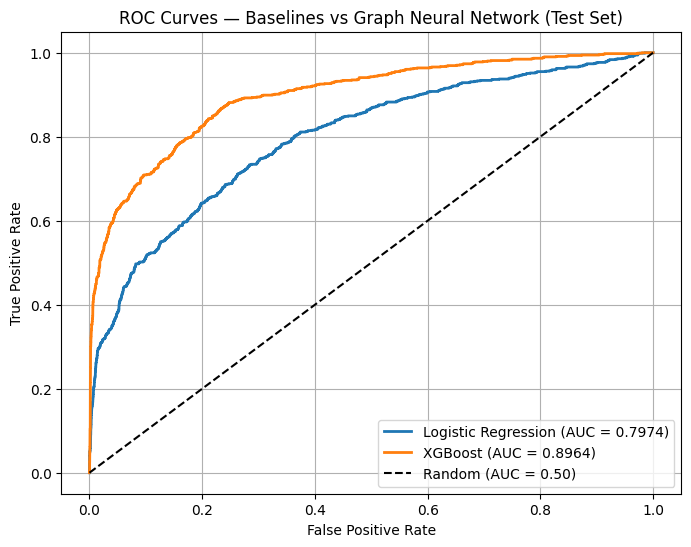

In [14]:
from sklearn.metrics import roc_curve, auc

print("\n--- MODEL COMPARISON (Test Set) ---\n")
rows = []
for name, r in results.items():
    labels = r.get('test_labels', y_test.values)
    proba  = r['test_pred_proba']
    preds  = (proba > 0.5).astype(int)   # numpy: .astype(int), never .long()
    rows.append({'Model': name,
                 'AUC': f"{roc_auc_score(labels, proba):.4f}",
                 'F1-Score': f"{f1_score(labels, preds):.4f}",
                 'Recall': f"{recall_score(labels, preds):.4f}"})

display(pd.DataFrame(rows))

plt.figure(figsize=(8, 6))
for name, r in results.items():
    labels = r.get('test_labels', y_test.values)
    fpr, tpr, _ = roc_curve(labels, r['test_pred_proba'])
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Baselines vs Graph Neural Network (Test Set)')
plt.legend(loc='lower right'); plt.grid(True); plt.show()